# Python-opslagsark

Alt det centrale fra forberedelsen og seminardagen den 15. september 2026, samlet ét sted. Notebooken er tænkt som et opslagsværk: find den operation, du skal bruge, og kopiér cellen. Alle celler kan køres igen (kør opsætningscellen først), og resultaterne står allerede under cellerne.

**Indhold:** 1. Opsætning · 2. Variabler, tal og tekst · 3. Lister og arrays · 4. Regning med arrays · 5. Funktioner og grafer · 6. Data med pandas · 7. Fejlmeddelelser · 8. Videre herfra

## 1. Opsætning

De tre værktøjskasser med deres faste kaldenavne. Denne celle skal køres først, hver gang notebooken åbnes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Datafilen fra seminardagen, hentet direkte fra kursets GitHub:
DATA_URL = "https://raw.githubusercontent.com/EskilAndersen/Edutasia/main/ishuset.xlsx"
print("Klar.")

Klar.


## 2. Variabler, tal og tekst

In [2]:
# Variabler og de fem typer
pris = 45                 # int: helt tal
vaegt = 3.5               # float: decimaltal (altid punktum i kode)
butik = "Aalborg C"       # str: tekst, altid i anførselstegn
aaben = True              # bool: sandt eller falsk
priser = [38, 50, 62]     # list: flere værdier i én variabel
print(type(pris), type(vaegt), type(butik), type(aaben), type(priser))

<class 'int'> <class 'float'> <class 'str'> <class 'bool'> <class 'list'>


In [3]:
# f-string: flet beregninger ind i tekst
antal = 4
print(f"I alt: {pris * antal} kr")

I alt: 180 kr


Husk: en notebook viser selv resultatet af den **sidste linje** i en celle. `print` bruges, når du vil se flere resultater fra én celle eller blande tekst og tal.

## 3. Lister og arrays

En liste er en samling. En numpy-array er en samling, man kan **regne** på. Forskellen ses tydeligst med gange:

In [4]:
# Kontrasten: liste vs array
print([1, 2, 3] * 2)             # liste: gentager indholdet
print(np.array([1, 2, 3]) * 2)   # array: ganger hvert tal

[1, 2, 3, 1, 2, 3]
[2 4 6]


In [5]:
# Indeksering: Python tæller fra 0
priser = np.array([38, 50, 62, 45, 55, 35])   # Ishusets menu
print(priser[0])      # første element
print(priser[2])      # tredje element
print(priser[1:4])    # udsnit: element 1, 2 og 3 (slutter FØR 4)

38
62
[50 62 45]


In [6]:
# 2D-array: [række, kolonne]
salg = np.array([[12, 8, 5],
                 [20, 15, 9]])   # to butikker, tre varer
print(salg[0, 2])    # række 0, kolonne 2
print(salg[1, :])    # hele række 1
print(salg[:, 0])    # hele kolonne 0

5
[20 15  9]
[12 20]


## 4. Regning med arrays

In [7]:
# Elementvis regning: operationen rammer hvert tal
priser = np.array([38, 50, 62])
print(priser * 1.10)          # alle priser hævet 10 %
print(priser - 5)             # alle priser sat 5 kr ned

[41.8 55.  68.2]
[33 45 57]


In [8]:
# Regning med rækker
print(salg[0, :] + salg[1, :])   # samlet salg pr. vare på tværs af butikker
print(salg[1, :] * 2)            # række 1 fordoblet

[32 23 14]
[40 30 18]


In [9]:
# Prikprodukt med @: gang parvis og læg sammen
antal = np.array([2, 1, 3])          # en familie køber is
priser = np.array([38, 50, 62])
print(antal @ priser)                # 2*38 + 1*50 + 3*62

312


## 5. Funktioner og grafer

Mønstret fra seminardagen: definér en funktion, lav x-værdier med `linspace`, beregn y, og tegn.

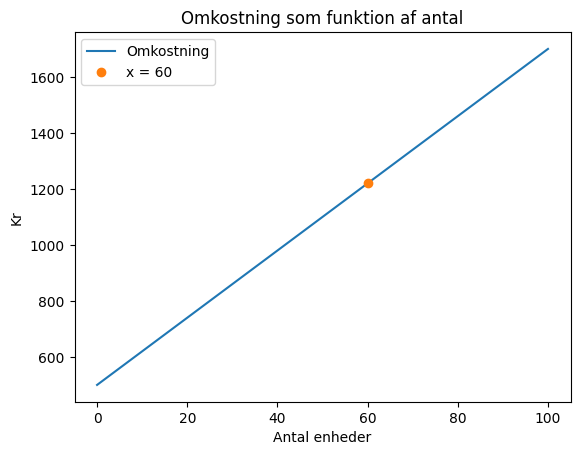

In [10]:
# Hele mønstret i én celle: def -> linspace -> plot
def omkostning(x):
    return 500 + 12 * x          # faste + variable omkostninger

x = np.linspace(0, 100, 50)      # 50 punkter fra 0 til 100
y = omkostning(x)

plt.plot(x, y, label="Omkostning")
plt.plot(60, omkostning(60), "o", label="x = 60")   # markér ét punkt
plt.xlabel("Antal enheder")
plt.ylabel("Kr")
plt.title("Omkostning som funktion af antal")
plt.legend()
plt.show()

## 6. Data med pandas

Rækkefølgen fra seminardagen: indlæs, kig, beregn.

In [11]:
# Indlæs Excel-fil i en DataFrame
df = pd.read_excel(DATA_URL)
# Fra egen uploadet fil i stedet: df = pd.read_excel("ishuset.xlsx")
df.head()    # de første 5 rækker

,SalgsId,Dato,Butik,Vare,Antal,EnhedsPris
0,2017,2026-06-01,Aalborg C,Softice,2,45
1,2051,2026-06-01,Skagen,Softice,4,45
2,2130,2026-06-01,Skagen,Vaffel 3 kugler,3,62
3,2148,2026-06-01,Blokhus,Vaffel 3 kugler,2,62
4,2189,2026-06-01,Aalborg C,Vaffel 1 kugle,2,38


In [12]:
# Overblik
print(df.shape)    # (rækker, kolonner)
df.describe()      # nøgletal for talkolonnerne

(300, 6)


,SalgsId,Dato,Antal,EnhedsPris
count,300.000000,300,300.000000,300.000000
mean,2150.500000,2026-07-01 20:48:00,2.533333,48.450000
min,2001.000000,2026-06-01 00:00:00,1.000000,35.000000
25%,2075.750000,2026-06-17 00:00:00,1.000000,45.000000
50%,2150.500000,2026-07-01 12:00:00,3.000000,50.000000
75%,2225.250000,2026-07-17 06:00:00,4.000000,55.000000
max,2300.000000,2026-07-31 00:00:00,4.000000,62.000000
std,86.746758,NaN,1.145978,8.020094


In [13]:
# Én kolonne og dens nøgletal
print(df["Antal"].mean())
print(df["Antal"].sum())
print(df["Antal"].min())
print(df["Antal"].max())

2.533333333333333
760
1
4


In [14]:
# Tæl kategorier
df["Vare"].value_counts()

Vare
Vaffel 2 kugler    101
Softice             63
Vaffel 3 kugler     41
Slushice            38
Milkshake           36
Vaffel 1 kugle      21
Name: count, dtype: int64

In [15]:
# Beregnet kolonne
df["Omsætning"] = df["Antal"] * df["EnhedsPris"]
df.head()

,SalgsId,Dato,Butik,Vare,Antal,EnhedsPris,Omsætning
0,2017,2026-06-01,Aalborg C,Softice,2,45,90
1,2051,2026-06-01,Skagen,Softice,4,45,180
2,2130,2026-06-01,Skagen,Vaffel 3 kugler,3,62,186
3,2148,2026-06-01,Blokhus,Vaffel 3 kugler,2,62,124
4,2189,2026-06-01,Aalborg C,Vaffel 1 kugle,2,38,76


In [16]:
# Filtrering: kun rækker, der opfylder en betingelse
blokhus = df[df["Butik"] == "Blokhus"]
print(blokhus.shape)
print(f"Omsætning i Blokhus: {blokhus['Omsætning'].sum()} kr")

(78, 7)
Omsætning i Blokhus: 10217 kr


In [17]:
# Opslag: find én bestemt række
df[df["SalgsId"] == 2130]

,SalgsId,Dato,Butik,Vare,Antal,EnhedsPris,Omsætning
2,2130,2026-06-01,Skagen,Vaffel 3 kugler,3,62,186


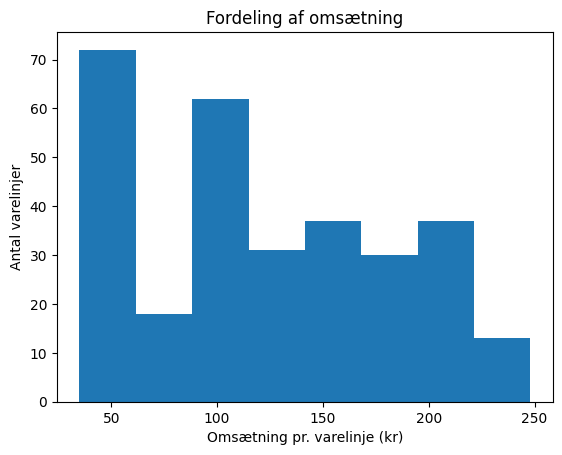

In [18]:
# Histogram af en talkolonne
plt.hist(df["Omsætning"], bins=8)
plt.xlabel("Omsætning pr. varelinje (kr)")
plt.ylabel("Antal varelinjer")
plt.title("Fordeling af omsætning")
plt.show()

## 7. Fejlmeddelelser

Læs altid den **nederste linje** af fejlmeddelelsen først.

| Fejl | Betyder som regel | Gør |
| --- | --- | --- |
| `NameError` | Stavefejl i et navn, eller cellen med definitionen er ikke kørt | Tjek stavning (store/små bogstaver tæller), kør cellerne oppefra |
| `SyntaxError` | Noget mangler eller står forkert: parentes, anførselstegn, kolon | Kig på linjen, fejlen peger på, og tegnet lige før |
| `FileNotFoundError` | Filen er ikke uploadet, eller navnet er stavet forkert | Upload filen igen i Files-panelet, tjek filnavnet |

Virker intet: **Runtime > Restart session**, og kør så alle celler oppefra.